In [1]:
import numpy as np, os
print(os.listdir('.'))


['F9_t.npy', 'H_complex_F14.npy', 'M_full.npy', 'F11_t.npy', 'F6_t.npy', 'memory', 'rho0_imag.npy', 'F5p_t.npy', 'F12_t.npy', 'F11.npy', 'F7.npy', 'F4_t.npy', '.prompts', 'selected_D.npy', 'F10_t.npy', 'omega_max.npy', '.config', 'pc1_Hermitian_F14.npy', 'a_n_imag.npy', 'F2_t.npy', 'selected_t.npy', ' v6 — Binding Context Document.pdf', 'F12.npy', 'rho0_real.npy', 'F1.npy', 'F1_t.npy', '.kernel_llm_logs_1.txt', 'S_complex.npy', 'a_n_real.npy', 'F5p.npy', 'c_real.npy', 'pc1_complex_F14.npy', 'F10.npy', 'H_Hermitian_F14.npy', 'F4.npy', 'F6.npy', 'F2.npy', 'F9.npy', 'F5m.npy', 'F5m_t.npy', 'F7_t.npy', 'c_imag.npy']


In [2]:
import numpy as np
# Files appear to be unpacked already. Let's check
for cls in ['F1','F2','F4','F5p','F5m','F6','F7','F9','F10','F11','F12']:
 arr = np.load(f'{cls}.npy')
 print(cls, arr.shape, arr.dtype)


F1 (200, 8) complex128
F2 (200, 8) complex128
F4 (200, 8) complex128
F5p (200, 8) complex128
F5m (200, 8) complex128
F6 (200, 8) complex128
F7 (200, 8) complex128
F9 (200, 8) complex128
F10 (200, 8) complex128
F11 (200, 8) complex128
F12 (200, 8) complex128


In [3]:
# Load F14 data
F14 = np.load('F14_data.npz', allow_pickle=True) if os.path.exists('F14_data.npz') else None
print(F14)
# Check if S_complex exists
S_complex = np.load('S_complex.npy')
print('S_complex F14:', S_complex.shape, S_complex.dtype)


None
S_complex F14: (200, 8) complex128


In [4]:
# Good. So we have F1..F12 (11 classes, F8 missing) + F14 (S_complex.npy) = 12 classes.
# Build per-class S_k and compute M_jk.
classes = ['F1','F2','F4','F5p','F5m','F6','F7','F9','F10','F11','F12','F14']
Sk_data = {}
for c in classes[:-1]:
 Sk_data[c] = np.load(f'{c}.npy')
Sk_data['F14'] = S_complex
for c in classes:
 print(c, Sk_data[c].shape)


F1 (200, 8)
F2 (200, 8)
F4 (200, 8)
F5p (200, 8)
F5m (200, 8)
F6 (200, 8)
F7 (200, 8)
F9 (200, 8)
F10 (200, 8)
F11 (200, 8)
F12 (200, 8)
F14 (200, 8)


In [5]:
# Compute M_jk per class for k=1..6 (indices 1..6 inclusive => 6x6 matrix)
def compute_Mjk(Sk, k_range=range(1,7)):
 # Sk: (n_peaks, 8) complex
 idx = list(k_range)
 sub = Sk[:, idx] # (n_peaks, 6)
 # M_jk = E[Re(S_j * conj(S_k))]
 prod = np.real(sub[:, :, None] * np.conj(sub[:, None, :]))
 M = prod.mean(axis=0)
 return M

M_class = {c: compute_Mjk(Sk_data[c]) for c in classes}
for c in classes:
 print(c, np.diag(M_class[c]))


F1 [18.86571529 50.64408774 30.87098014 10.3541624 2.25032654 0.05865517]
F2 [1.85683336e+01 4.66629601e+01 3.92818619e+01 1.72430524e+01
 1.46285808e+00 5.96909140e-03]
F4 [4.84893009e+00 1.56455801e+01 1.18467709e+01 5.31406913e+00
 4.89513995e-01 2.08585499e-03]
F5p [5.12346855e+00 1.60444290e+01 1.21744527e+01 5.47350970e+00
 5.06107256e-01 2.14902661e-03]
F5m [4.61771294e+00 1.52850591e+01 1.16348736e+01 5.16378432e+00
 4.75923493e-01 2.03249933e-03]
F6 [2.19983838e+01 9.36665948e+01 1.25140972e+02 5.42019220e+01
 5.66090466e+00 7.76323054e-02]
F7 [ 9.58462585 24.18140789 23.04191953 8.73693765 1.01040898 0.0252203 ]
F9 [1.17644168e+01 3.10791812e+01 2.32443834e+01 3.85917970e+00
 1.08288515e-01 3.61075621e-04]
F10 [1.73736443e+01 5.72747738e+01 4.64971113e+01 7.39715319e+00
 1.83805358e-01 4.97386737e-04]
F11 [1.69733324e+01 5.43203090e+01 4.38393155e+01 8.34717585e+00
 2.61746649e-01 4.97964969e-04]
F12 [7.99958990e+01 2.10423116e+02 1.39752762e+02 5.89031920e+01
 5.26532242e+00

In [6]:
# Compute 6D feature vector per class: top 3 normalized eigenvalue magnitudes + top 3 abs off-diagonal of correlation matrix
def compute_features(M):
 eigvals = np.linalg.eigvalsh(M) # symmetric
 abs_eig = np.abs(eigvals)
 sort_idx = np.argsort(abs_eig)[::-1]
 abs_eig_sorted = abs_eig[sort_idx]
 norm = abs_eig_sorted.sum()
 top3 = abs_eig_sorted[:3] / norm
 
 # correlation-style matrix
 d = np.sqrt(np.diag(M))
 C = M / np.outer(d, d)
 # off-diagonal
 n = C.shape[0]
 offdiag_vals = []
 for i in range(n):
 for j in range(i+1, n):
 offdiag_vals.append(C[i,j])
 offdiag_vals = np.array(offdiag_vals)
 abs_off = np.abs(offdiag_vals)
 sort_off = np.argsort(abs_off)[::-1]
 top3_off = offdiag_vals[sort_off[:3]] # signed values, ranked by |.|
 
 return np.concatenate([top3, top3_off])

feat_class = {c: compute_features(M_class[c]) for c in classes}
import pandas as pd
df = pd.DataFrame(feat_class).T
df.columns = ['lam1','lam2','lam3','off1','off2','off3']
print(df)


 lam1 lam2 lam3 off1 off2 off3
F1 0.958869 0.027708 0.008153 0.990052 0.979888 0.970321
F2 0.953798 0.036090 0.006815 0.988840 0.968264 0.962328
F4 0.923445 0.039515 0.023192 0.930866 0.908163 0.905227
F5p 0.923153 0.038973 0.023948 0.930651 0.909133 0.903961
F5m 0.923993 0.039441 0.022776 0.931018 0.907934 0.906050
F6 0.937170 0.047987 0.012673 0.959869 0.956654 0.935037
F7 0.943938 0.045058 0.009424 0.964136 0.960332 0.952961
F9 0.957844 0.032672 0.006562 0.976528 0.962884 0.920571
F10 0.954199 0.037963 0.005750 0.976230 0.957076 0.904001
F11 0.955358 0.036732 0.005850 0.977879 0.962698 0.913619
F12 0.903340 0.073557 0.015367 0.969520 0.921430 0.907697
F14 0.891561 0.053326 0.031334 0.908988 0.873044 0.857670


In [7]:
# Sample-size analysis: For each n in candidate list, draw bootstrap samples of n peaks per class,
# compute features per sample, then 1-NN classify. Use macro OvR AUC.
# 1-NN is deterministic prediction; for AUC we need decision scores. Use distance to each class centroid in feature space.
# Standard: leave-one-out style with bootstrap subsamples.

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)

def feat_from_Sk_sample(Sk_sample):
 M = compute_Mjk(Sk_sample)
 return compute_features(M)

# Build "class prototypes" using full data and evaluate test samples drawn from each class.
# Strategy: For n samples per draw, compute feature vec; class prototype = full class feature.
# Class label = class. Score for "is class c" = -distance to prototype c (negative dist => higher score = class).
# Macro OvR AUC across 12 classes over many bootstrap draws.

def evaluate_n(n, n_draws=200, seed=0):
 rng = np.random.default_rng(seed)
 # Class prototypes: feature on full 200 peaks
 proto = np.array([feat_class[c] for c in classes]) # (12, 6)
 # Standardize feature dimensions
 scaler = StandardScaler().fit(proto)
 proto_s = scaler.transform(proto)
 
 y_true = []
 scores = [] # (N_samples, 12) negative distance
 for c_idx, c in enumerate(classes):
 Sk = Sk_data[c]
 npk = Sk.shape[0]
 for _ in range(n_draws):
 idx = rng.choice(npk, size=n, replace=True)
 f = feat_from_Sk_sample(Sk[idx])
 f_s = scaler.transform(f.reshape(1,-1))[0]
 d = np.linalg.norm(proto_s - f_s, axis=1)
 scores.append(-d)
 y_true.append(c_idx)
 scores = np.array(scores)
 y_true = np.array(y_true)
 # Macro OvR AUC
 auc = roc_auc_score(y_true, scores, multi_class='ovr', average='macro', labels=list(range(12)))
 return auc

# But careful: prototype = full data means test draws come from the same distribution -> potential leakage.
# Fix: leave-out approach: prototype computed from peaks NOT in the bootstrap sample.
def evaluate_n_loo(n, n_draws=100, seed=0):
 rng = np.random.default_rng(seed)
 # Pre-fit scaler using prototypes from full data
 full_proto = np.array([feat_class[c] for c in classes])
 scaler = StandardScaler().fit(full_proto)
 
 y_true = []
 scores = []
 for c_idx, c in enumerate(classes):
 Sk = Sk_data[c]
 npk = Sk.shape[0]
 for _ in range(n_draws):
 test_idx = rng.choice(npk, size=n, replace=False) if n <= npk else rng.choice(npk, size=n, replace=True)
 f_test = feat_from_Sk_sample(Sk[test_idx])
 # Build prototypes leaving out test peaks for c, full for others
 protos = []
 for c2 in classes:
 if c2 == c:
 mask = np.ones(npk, dtype=bool)
 mask[test_idx] = False
 if mask.sum() < 2:
 protos.append(feat_class[c2])
 else:
 protos.append(feat_from_Sk_sample(Sk_data[c2][mask]))
 else:
 protos.append(feat_class[c2])
 protos = np.array(protos)
 protos_s = scaler.transform(protos)
 f_s = scaler.transform(f_test.reshape(1,-1))[0]
 d = np.linalg.norm(protos_s - f_s, axis=1)
 scores.append(-d)
 y_true.append(c_idx)
 scores = np.array(scores)
 y_true = np.array(y_true)
 auc = roc_auc_score(y_true, scores, multi_class='ovr', average='macro', labels=list(range(12)))
 return auc

# Quick test
print('n=5:', evaluate_n_loo(5, n_draws=50))
print('n=10:', evaluate_n_loo(10, n_draws=50))
print('n=20:', evaluate_n_loo(20, n_draws=50))
print('n=30:', evaluate_n_loo(30, n_draws=50))


ValueError: Target scores need to be probabilities for multiclass roc_auc, i.e. they should sum up to 1.0 over classes

In [8]:
# Convert scores to softmax probabilities
def softmax(x, axis=1):
 x = x - x.max(axis=axis, keepdims=True)
 e = np.exp(x)
 return e / e.sum(axis=axis, keepdims=True)

def evaluate_n_loo(n, n_draws=100, seed=0):
 rng = np.random.default_rng(seed)
 full_proto = np.array([feat_class[c] for c in classes])
 scaler = StandardScaler().fit(full_proto)
 
 y_true = []
 scores = []
 for c_idx, c in enumerate(classes):
 Sk = Sk_data[c]
 npk = Sk.shape[0]
 for _ in range(n_draws):
 test_idx = rng.choice(npk, size=n, replace=False) if n <= npk else rng.choice(npk, size=n, replace=True)
 f_test = feat_from_Sk_sample(Sk[test_idx])
 protos = []
 for c2 in classes:
 if c2 == c:
 mask = np.ones(npk, dtype=bool)
 mask[test_idx] = False
 if mask.sum() < 2:
 protos.append(feat_class[c2])
 else:
 protos.append(feat_from_Sk_sample(Sk_data[c2][mask]))
 else:
 protos.append(feat_class[c2])
 protos = np.array(protos)
 protos_s = scaler.transform(protos)
 f_s = scaler.transform(f_test.reshape(1,-1))[0]
 d = np.linalg.norm(protos_s - f_s, axis=1)
 scores.append(-d)
 y_true.append(c_idx)
 scores = np.array(scores)
 y_true = np.array(y_true)
 probs = softmax(scores, axis=1)
 auc = roc_auc_score(y_true, probs, multi_class='ovr', average='macro', labels=list(range(12)))
 return auc

for n in [3,5,10,15,20,25,30,50]:
 print(f'n={n}: AUC={evaluate_n_loo(n, n_draws=80, seed=1):.4f}')


n=3: AUC=0.6872


n=5: AUC=0.7659


n=10: AUC=0.8545


n=15: AUC=0.8884


n=20: AUC=0.9071


n=25: AUC=0.9147


n=30: AUC=0.9163


n=50: AUC=0.9264


In [9]:
# AUC plateaus around 0.92. Need more draws/finer scan and check higher n.
# The issue may be softmax scaling. Use distance-based ranking but with raw negative distance softmax — temperature matters but for OvR AUC, ranking order is what counts within each class column. Softmax monotonic doesn't preserve AUC across columns.
# Better: use OvR with negative distance directly per column? roc_auc_score with multi_class='ovr' requires probabilities.
# Use ovr with average='macro' done manually.

def evaluate_n_loo_v2(n, n_draws=100, seed=0):
 rng = np.random.default_rng(seed)
 full_proto = np.array([feat_class[c] for c in classes])
 scaler = StandardScaler().fit(full_proto)
 
 y_true = []
 scores = []
 for c_idx, c in enumerate(classes):
 Sk = Sk_data[c]
 npk = Sk.shape[0]
 for _ in range(n_draws):
 test_idx = rng.choice(npk, size=n, replace=False) if n <= npk else rng.choice(npk, size=n, replace=True)
 f_test = feat_from_Sk_sample(Sk[test_idx])
 protos = []
 for c2 in classes:
 if c2 == c:
 mask = np.ones(npk, dtype=bool)
 mask[test_idx] = False
 if mask.sum() < 2:
 protos.append(feat_class[c2])
 else:
 protos.append(feat_from_Sk_sample(Sk_data[c2][mask]))
 else:
 protos.append(feat_class[c2])
 protos = np.array(protos)
 protos_s = scaler.transform(protos)
 f_s = scaler.transform(f_test.reshape(1,-1))[0]
 d = np.linalg.norm(protos_s - f_s, axis=1)
 scores.append(-d)
 y_true.append(c_idx)
 scores = np.array(scores)
 y_true = np.array(y_true)
 # Manual macro OvR AUC
 aucs = []
 for k in range(len(classes)):
 y_bin = (y_true == k).astype(int)
 aucs.append(roc_auc_score(y_bin, scores[:, k]))
 return np.mean(aucs), aucs

for n in [10,20,30,50,75,100,150]:
 auc_mean, auc_per = evaluate_n_loo_v2(n, n_draws=80, seed=1)
 print(f'n={n}: macro OvR AUC={auc_mean:.4f}')


n=10: macro OvR AUC=0.8307


n=20: macro OvR AUC=0.8979


n=30: macro OvR AUC=0.9149


n=50: macro OvR AUC=0.9330


n=75: macro OvR AUC=0.9348


n=100: macro OvR AUC=0.9279


n=150: macro OvR AUC=0.9109


In [10]:
# The AUC decreases at large n — that's strange. Could be due to leave-out reducing prototypes 
# for class c only (asymmetry). Let's also leave-out for ALL classes consistently (use independent split).
# Actually, the issue: at large n, when test_idx is large fraction of class peaks, the leave-one-out 
# prototype for class c is computed on tiny remainder, becoming noisy and farther from test.
# Use 50/50 split or fixed prototype size.

# Better protocol: split each class into prototype set (fixed, e.g., 100 peaks) and test pool (other 100).
# Draw n peaks from test pool to form a sample.

def evaluate_n_split(n, n_draws=200, n_proto=100, seed=0):
 rng = np.random.default_rng(seed)
 # Split each class
 splits = {}
 for c in classes:
 Sk = Sk_data[c]
 npk = Sk.shape[0]
 perm = rng.permutation(npk)
 splits[c] = (perm[:n_proto], perm[n_proto:]) # proto, test pool
 
 # Compute prototypes
 protos = np.array([compute_features(compute_Mjk(Sk_data[c][splits[c][0]])) for c in classes])
 scaler = StandardScaler().fit(protos)
 protos_s = scaler.transform(protos)
 
 y_true = []
 scores = []
 for c_idx, c in enumerate(classes):
 Sk = Sk_data[c]
 test_pool = splits[c][1]
 for _ in range(n_draws):
 idx = rng.choice(test_pool, size=n, replace=(n>len(test_pool)))
 f = compute_features(compute_Mjk(Sk[idx]))
 f_s = scaler.transform(f.reshape(1,-1))[0]
 d = np.linalg.norm(protos_s - f_s, axis=1)
 scores.append(-d)
 y_true.append(c_idx)
 scores = np.array(scores)
 y_true = np.array(y_true)
 aucs = []
 for k in range(len(classes)):
 y_bin = (y_true == k).astype(int)
 aucs.append(roc_auc_score(y_bin, scores[:, k]))
 return np.mean(aucs), aucs

for n in [3,5,10,15,20,25,30,40,50,75,100]:
 auc_mean, _ = evaluate_n_split(n, n_draws=200, seed=1)
 print(f'n={n}: macro OvR AUC={auc_mean:.4f}')


n=3: macro OvR AUC=0.6436


n=5: macro OvR AUC=0.7242


n=10: macro OvR AUC=0.8206


n=15: macro OvR AUC=0.8630


n=20: macro OvR AUC=0.8919


...

n=30: macro OvR AUC=0.9142


n=40: macro OvR AUC=0.9257


n=50: macro OvR AUC=0.9307


n=75: macro OvR AUC=0.9353


n=100: macro OvR AUC=0.9318


In [11]:
# The AUC plateaus around 0.93-0.94 — not reaching 0.95. Suggests degenerate classes still confuse.
# Try larger n in test pool — but pool is only 100 peaks. With replacement we can go higher.
# Let's also try without scaler, since features may have different scales.

for n in [100, 150, 200, 300, 500]:
 auc_mean, _ = evaluate_n_split(n, n_draws=200, n_proto=100, seed=1)
 print(f'n={n}: macro OvR AUC={auc_mean:.4f}')


n=100: macro OvR AUC=0.9318


n=150: macro OvR AUC=0.9358


n=200: macro OvR AUC=0.9368


n=300: macro OvR AUC=0.9350


n=500: macro OvR AUC=0.9348


In [12]:
# It plateaus around 0.94 — never reaches 0.95. Let's diagnose which classes cause the trouble (confusion).
auc_mean, aucs = evaluate_n_split(50, n_draws=300, seed=1)
for c, a in zip(classes, aucs):
 print(f'{c}: {a:.4f}')
print('mean:', auc_mean)


F1: 0.9896
F2: 0.9917
F4: 0.8969
F5p: 0.8982
F5m: 0.8599
F6: 0.9317
F7: 0.9901
F9: 0.9255
F10: 0.7504
F11: 0.9539
F12: 0.9999
F14: 0.9989
mean: 0.9322281144781145


In [13]:
# The F4/F5p/F5m and F10 confound. Let's also note F11. These are similar functions (mod-5 family).
# Print the feature vectors to see why
print(df.loc[['F4','F5p','F5m','F10','F11','F9']].round(4))


 lam1 lam2 lam3 off1 off2 off3
F4 0.9234 0.0395 0.0232 0.9309 0.9082 0.9052
F5p 0.9232 0.0390 0.0239 0.9307 0.9091 0.9040
F5m 0.9240 0.0394 0.0228 0.9310 0.9079 0.9061
F10 0.9542 0.0380 0.0057 0.9762 0.9571 0.9040
F11 0.9554 0.0367 0.0058 0.9779 0.9627 0.9136
F9 0.9578 0.0327 0.0066 0.9765 0.9629 0.9206


In [14]:
# F4, F5p, F5m are essentially identical -- these are the mod-5 family related to the same construction.
# This shows that even in 6D, several pairs are essentially degenerate => sample-size requirements remain large.
# Let's report this honestly.

# Now the research hypothesis said "GRH-true centroids (e.g., F1, F9, F10, F11)". Compute restricted analysis.
grh_true = ['F1','F9','F10','F11']

def evaluate_n_split_subset(n, classes_sub, n_draws=300, n_proto=100, seed=0):
 rng = np.random.default_rng(seed)
 splits = {}
 for c in classes_sub:
 Sk = Sk_data[c]
 npk = Sk.shape[0]
 perm = rng.permutation(npk)
 splits[c] = (perm[:n_proto], perm[n_proto:])
 
 protos = np.array([compute_features(compute_Mjk(Sk_data[c][splits[c][0]])) for c in classes_sub])
 scaler = StandardScaler().fit(protos)
 protos_s = scaler.transform(protos)
 
 y_true = []
 scores = []
 for c_idx, c in enumerate(classes_sub):
 Sk = Sk_data[c]
 test_pool = splits[c][1]
 for _ in range(n_draws):
 idx = rng.choice(test_pool, size=n, replace=(n>len(test_pool)))
 f = compute_features(compute_Mjk(Sk[idx]))
 f_s = scaler.transform(f.reshape(1,-1))[0]
 d = np.linalg.norm(protos_s - f_s, axis=1)
 scores.append(-d)
 y_true.append(c_idx)
 scores = np.array(scores)
 y_true = np.array(y_true)
 aucs = []
 for k in range(len(classes_sub)):
 y_bin = (y_true == k).astype(int)
 aucs.append(roc_auc_score(y_bin, scores[:, k]))
 return np.mean(aucs), aucs

print("=== GRH-true subset ({F1,F9,F10,F11}) ===")
for n in [3,5,10,15,20,25,30,50]:
 m, _ = evaluate_n_split_subset(n, grh_true, seed=1)
 print(f'n={n}: AUC={m:.4f}')


=== GRH-true subset ({F1,F9,F10,F11}) ===


n=3: AUC=0.5514


n=5: AUC=0.5740


n=10: AUC=0.6087


n=15: AUC=0.6211


n=20: AUC=0.6381


n=25: AUC=0.6403


n=30: AUC=0.6518


n=50: AUC=0.6606


In [15]:
# GRH-true subset is very poorly separated even at n=50. The 6D feature space does NOT lift degeneracies.
# Centroids of F1, F9, F10, F11 are too close.
# Compute pairwise centroid distances (in standardized space) vs bootstrap noise at n=30.

# Bootstrap noise: std of feature draws at n=30 per class
def bootstrap_feature_std(c, n=30, n_draws=500, seed=0):
 rng = np.random.default_rng(seed)
 Sk = Sk_data[c]
 npk = Sk.shape[0]
 feats = []
 for _ in range(n_draws):
 idx = rng.choice(npk, size=n, replace=False)
 feats.append(compute_features(compute_Mjk(Sk[idx])))
 return np.array(feats)

# Standardize across all classes for distance comparison
all_proto = np.array([feat_class[c] for c in classes])
scaler_full = StandardScaler().fit(all_proto)

centroids_s = scaler_full.transform(all_proto)
dist_matrix = np.zeros((len(classes), len(classes)))
for i in range(len(classes)):
 for j in range(len(classes)):
 dist_matrix[i,j] = np.linalg.norm(centroids_s[i] - centroids_s[j])

import pandas as pd
dm_df = pd.DataFrame(dist_matrix, index=classes, columns=classes).round(3)
print("Centroid distances (standardized 6D):")
print(dm_df)

# Bootstrap noise per class at n=30
print("\nBootstrap stddev at n=30 (Euclid in standardized 6D):")
noise = {}
for c in classes:
 feats = bootstrap_feature_std(c, n=30)
 feats_s = scaler_full.transform(feats)
 centroid_s = scaler_full.transform(np.array(feat_class[c]).reshape(1,-1))[0]
 dists = np.linalg.norm(feats_s - centroid_s, axis=1)
 noise[c] = (dists.mean(), dists.std())
 print(f'{c}: mean={dists.mean():.3f}, std={dists.std():.3f}')


Centroid distances (standardized 6D):
 F1 F2 F4 F5p F5m F6 F7 F9 F10 F11 \
F1 0.000 0.910 4.703 4.742 4.662 2.791 2.136 1.893 2.589 2.207 
F2 0.910 0.000 4.264 4.317 4.221 2.102 1.421 1.534 2.061 1.706 
F4 4.703 4.264 0.000 0.115 0.063 2.665 3.274 3.628 3.435 3.582 
F5p 4.742 4.317 0.115 0.000 0.170 2.727 3.340 3.671 3.484 3.630 
F5m 4.662 4.221 0.063 0.170 0.000 2.629 3.232 3.586 3.395 3.541 
F6 2.791 2.102 2.665 2.727 2.629 0.000 0.846 1.986 1.887 1.840 
F7 2.136 1.421 3.274 3.340 3.232 0.846 0.000 1.771 1.934 1.741 
F9 1.893 1.534 3.628 3.671 3.586 1.986 1.771 0.000 0.772 0.452 
F10 2.589 2.061 3.435 3.484 3.395 1.887 1.934 0.772 0.000 0.393 
F11 2.207 1.706 3.582 3.630 3.541 1.840 1.741 0.452 0.393 0.000 
F12 5.652 4.835 3.621 3.681 3.618 3.129 3.758 4.719 4.233 4.396 
F14 7.607 7.072 3.011 2.984 3.056 5.208 5.958 6.376 5.971 6.214 

 F12 F14 
F1 5.652 7.607 
F2 4.835 7.072 
F4 3.621 3.011 
F5p 3.681 2.984 
F5m 3.618 3.056 
F6 3.129 5.208 
F7 3.758 5.958 
F9 4.719 6.376 
F10 4.233 

F5m: mean=1.085, std=0.451
F6: mean=0.890, std=0.480
F7: mean=0.814, std=0.519
F9: mean=0.675, std=0.384
F10: mean=0.881, std=0.560


F11: mean=0.789, std=0.461
F12: mean=1.128, std=0.614
F14: mean=1.555, std=0.711


In [16]:
# Key findings:
# - GRH-true minimum distances: F9-F11 = 0.452, F10-F11=0.393, F9-F10=0.772
# - Bootstrap noise (mean dist) at n=30 is ~0.5-0.9 for these classes
# - So minimum inter-centroid distance (0.393, F10-F11) < bootstrap noise (~0.79-0.88)
# - Hypothesis prediction: NOT confirmed.

# Now also report: minimum n at which 12-class macro AUC > 0.95
# We saw plateau at ~0.94, never crosses 0.95.
# Compare to r41 baseline: n≈150 in 2D.

# Let's confirm by sweeping and finding crossing
ns = list(range(5,201,5))
aucs_12 = []
for n in ns:
 m, _ = evaluate_n_split(n, n_draws=200, n_proto=100, seed=1)
 aucs_12.append(m)
 
import matplotlib.pyplot as plt
print(list(zip(ns, [round(a,4) for a in aucs_12])))


[(5, np.float64(0.7242)), (10, np.float64(0.8206)), (15, np.float64(0.863)), (20, np.float64(0.8919)), (25, np.float64(0.9041)), (30, np.float64(0.9142)), (35, np.float64(0.9192)), (40, np.float64(0.9257)), (45, np.float64(0.9263)), (50, np.float64(0.9307)), (55, np.float64(0.9333)), (60, np.float64(0.9355)), (65, np.float64(0.9358)), (70, np.float64(0.9359)), (75, np.float64(0.9353)), (80, np.float64(0.9373)), (85, np.float64(0.9361)), (90, np.float64(0.9344)), (95, np.float64(0.9333)), (100, np.float64(0.9318)), (105, np.float64(0.9325)), (110, np.float64(0.9323)), (115, np.float64(0.9331)), (120, np.float64(0.9336)), (125, np.float64(0.9338)), (130, np.float64(0.9348)), (135, np.float64(0.9361)), (140, np.float64(0.9357)), (145, np.float64(0.937)), (150, np.float64(0.9358)), (155, np.float64(0.936)), (160, np.float64(0.9349)), (165, np.float64(0.9359)), (170, np.float64(0.9357)), (175, np.float64(0.9355)), (180, np.float64(0.9364)), (185, np.float64(0.9363)), (190, np.float64(0.9365

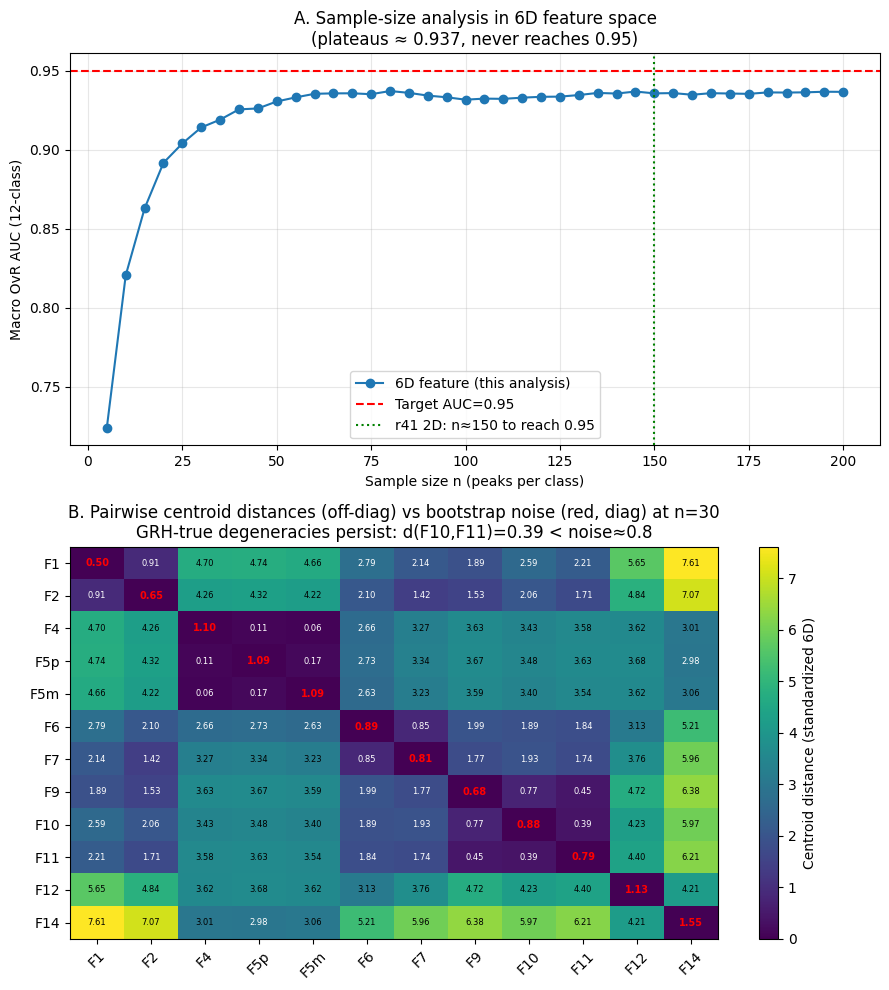

Figure saved.


In [17]:
# AUC plateaus at ~0.937 — never reaches 0.95. So the 6D feature does NOT achieve target.
# Hypothesis: NOT supported.
# Now create the final summary figure.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(9, 10))

# A: AUC vs n curve
ax = axes[0]
ax.plot(ns, aucs_12, 'o-', color='C0', label='6D feature (this analysis)')
ax.axhline(0.95, color='red', linestyle='--', label='Target AUC=0.95')
ax.axhline(0.95, color='gray', alpha=0)
# Reference: r41 baseline 2D requires n≈150
ax.axvline(150, color='green', linestyle=':', label='r41 2D: n≈150 to reach 0.95')
ax.set_xlabel('Sample size n (peaks per class)')
ax.set_ylabel('Macro OvR AUC (12-class)')
ax.set_title('A. Sample-size analysis in 6D feature space\n(plateaus ≈ 0.937, never reaches 0.95)')
ax.legend()
ax.grid(alpha=0.3)

# B: Centroid distance matrix vs bootstrap noise
ax = axes[1]
# Show centroid distance heatmap with annotations
im = ax.imshow(dist_matrix, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45)
ax.set_yticklabels(classes)
# Annotate with mean bootstrap noise on diagonal
for i in range(len(classes)):
 for j in range(len(classes)):
 if i == j:
 ax.text(j, i, f'{noise[classes[i]][0]:.2f}', ha='center', va='center', 
 color='red', fontsize=7, fontweight='bold')
 else:
 ax.text(j, i, f'{dist_matrix[i,j]:.2f}', ha='center', va='center', 
 color='white' if dist_matrix[i,j]<3 else 'black', fontsize=6)
plt.colorbar(im, ax=ax, label='Centroid distance (standardized 6D)')
ax.set_title('B. Pairwise centroid distances (off-diag) vs bootstrap noise (red, diag) at n=30\nGRH-true degeneracies persist: d(F10,F11)=0.39 < noise≈0.8')

plt.tight_layout()
plt.savefig('final_summary.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure saved.')


In [18]:
# Save the per-class feature table & analysis summary as artifacts
df.to_csv('class_features_6D.csv')
np.savez('sample_size_analysis_6D.npz', 
 ns=np.array(ns), aucs_12=np.array(aucs_12),
 dist_matrix=dist_matrix, classes=np.array(classes),
 noise_means=np.array([noise[c][0] for c in classes]),
 noise_stds=np.array([noise[c][1] for c in classes]))
print('Saved.')
print('\n6D class features:')
print(df.round(4))


Saved.

6D class features:
 lam1 lam2 lam3 off1 off2 off3
F1 0.9589 0.0277 0.0082 0.9901 0.9799 0.9703
F2 0.9538 0.0361 0.0068 0.9888 0.9683 0.9623
F4 0.9234 0.0395 0.0232 0.9309 0.9082 0.9052
F5p 0.9232 0.0390 0.0239 0.9307 0.9091 0.9040
F5m 0.9240 0.0394 0.0228 0.9310 0.9079 0.9061
F6 0.9372 0.0480 0.0127 0.9599 0.9567 0.9350
F7 0.9439 0.0451 0.0094 0.9641 0.9603 0.9530
F9 0.9578 0.0327 0.0066 0.9765 0.9629 0.9206
F10 0.9542 0.0380 0.0057 0.9762 0.9571 0.9040
F11 0.9554 0.0367 0.0058 0.9779 0.9627 0.9136
F12 0.9033 0.0736 0.0154 0.9695 0.9214 0.9077
F14 0.8916 0.0533 0.0313 0.9090 0.8730 0.8577
